# Differential CpG methylation in enhancer regions

This notebook correlates CpG methylation changes to DCM labelling differences at enhancer regions

## Input

- Statistics of MeD-seq samples (MeD-seq.statistics.txt)
- Enhancer counts, generated in notebook 13 (Enhancer_counts.txt)
- Table S6, generated in notebook 15 (SupplementalTable6.txt)

## Output

- Figure 5k. CpG DMRs at enhancers

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import median_abs_deviation, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

# Rpy2
%load_ext rpy2.ipython

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

comparisons = ["iPSC_DE", "DE_PGT"]
comparison_colors = [["#264653", "#E9C46A"], ["#E9C46A", "#E76F51"]] 

## Figure 5k. CpG DMRs at enhancers

In [3]:
# Get correction factors
stats = pd.read_csv(f"{input_dir}/MeD-seq.statistics.txt", sep="\t", header=0, index_col=0)
display(stats)

,Experiment,Condition,Sample,Total reads,DCM reads,CpG reads,Total million,DCM million,CpG million,DCM/CpG ratio,Genic DCM level,Correction factor
C4neg-1,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep1,42414674,1756919,40657755,42.414674,1.756919,40.657755,0.043212,0.000347,42.414674
C4neg-2,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep2,32645592,1431276,31214316,32.645592,1.431276,31.214316,0.045853,0.000328,32.645592
C4neg-3,iPSC clones,iPSC C4 -dox,iPSCs -dox C4 rep3,34929672,1383492,33546180,34.929672,1.383492,33.546180,0.041241,0.000301,34.929672
C4-1,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep1,42715841,26629059,16086782,42.715841,26.629059,16.086782,1.655338,0.004367,55.308220
C4-2,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep2,48475994,20953967,27522027,48.475994,20.953967,27.522027,0.761353,0.003014,43.324689
C4-3,iPSC clones,iPSC C4 +dox,iPSCs +dox C4 rep3,44165595,17234310,26931285,44.165595,17.234310,26.931285,0.639936,0.002737,35.839097
C6neg-1,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep1,36506398,1591859,34914539,36.506398,1.591859,34.914539,0.045593,0.000351,36.506398
C6neg-2,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep2,34477290,1273347,33203943,34.477290,1.273347,33.203943,0.038349,0.000286,34.477290
C6neg-3,iPSC clones,iPSC C6 -dox,iPSCs -dox C6 rep3,34594914,1483964,33110950,34.594914,1.483964,33.110950,0.044818,0.000322,34.594914
C6-1,iPSC clones,iPSC C6 +dox,iPSCs +dox C6 rep1,38526918,16985836,21541082,38.526918,16.985836,21.541082,0.788532,0.003195,36.500221


In [4]:
# Load CpG counts and normalize to the total nr of CpG reads
iPSC_DE = pd.read_csv(f"{output_dir}/SupplementalTable6.txt", sep="\t", index_col=0, header=0)
iPSC_DE = iPSC_DE[iPSC_DE["Region"].isin(["iPSC enhancer", "DE enhancer"])]

for sample in iPSC_DE.columns:
    if sample in stats.index:
        correction = stats.loc[sample, "CpG million"]
        iPSC_DE[sample] = iPSC_DE[sample] / correction

iPSC_DE["iPSC"] = iPSC_DE[["C4neg-1", "C4neg-2", "C4neg-3", "C4-1", "C4-2", "C4-3"]].mean(axis=1)
iPSC_DE["DE"] = iPSC_DE[["DE-c1", "DE-c2", "DE-c3", "DE-d1", "DE-d2", "DE-d3"]].mean(axis=1)
iPSC_DE["PGT"] = iPSC_DE[["PGT-c1", "PGT-c2", "PGT-c3"]].mean(axis=1)
display(iPSC_DE)

iPSC_DE_melt = iPSC_DE.melt(id_vars=["Region"], value_vars=["iPSC", "DE", "PGT"], var_name="Cell type", value_name="CpG")
display(iPSC_DE_melt)

,baseMean,log2FoldChange,lfcSE,pvalue,padj,Category,-log10(adjusted P-value),LogBaseMean,C4neg-1,C4neg-2,...,PGT-c1,PGT-c2,PGT-c3,NrSites,GeneName,GeneID,Region,iPSC,DE,PGT
3.164333100.164342041,224.369429,-1.760922,0.148635,8.253672e-33,3.062278e-28,iPSC,27.513955,2.350966,13.158621,11.853535,...,3.987743,3.907420,4.145924,73,.,.,DE enhancer,12.081944,3.906330,4.013696
9.78853643.78860095,172.248124,-1.681703,0.146396,6.229469e-31,1.540838e-26,iPSC,25.812243,2.236157,10.453110,9.258572,...,2.351746,3.394972,4.044803,38,.,.,DE enhancer,9.102422,3.135710,3.263840
22.42546495.42550243,193.042241,-1.503117,0.141986,1.699472e-26,1.801537e-22,iPSC,21.744357,2.285655,9.543075,7.913036,...,4.498992,4.419869,4.449284,32,.,.,DE enhancer,9.986312,3.802267,4.456048
20.39087712.39091761,44.962797,-1.994096,0.217458,1.266312e-20,9.396538e-17,iPSC,16.027032,1.652863,2.410364,3.427914,...,0.306749,0.800701,0.471894,15,.,.,DE enhancer,2.514078,0.669724,0.526448
10.93097114.93098063,30.366202,-2.576149,0.284973,1.493430e-20,1.007441e-16,iPSC,15.996780,1.482405,1.918453,2.691073,...,0.408999,0.672589,1.011201,11,.,.,DE enhancer,1.821661,0.310858,0.697596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13.79598594.79607051,181.745265,0.303961,0.189902,8.960532e-03,4.957626e-02,DE,1.304726,2.259465,7.329475,5.510292,...,15.201140,11.434009,11.089503,55,.,.,DE enhancer,5.163441,8.219727,12.574884
2.128985308.128988829,10.449640,0.677498,0.550244,8.969218e-03,4.961562e-02,DE,1.304382,1.019143,0.221360,0.320366,...,0.647582,0.576505,0.471894,13,.,.,DE enhancer,0.225354,0.558338,0.565327
5.178083795.178085788,66.356155,-0.315629,0.204280,9.047412e-03,4.991481e-02,iPSC,1.301771,1.821888,2.262791,2.370707,...,2.522162,1.985738,2.325762,17,.,.,iPSC enhancer,2.731035,2.076017,2.277887
5.115734615.115739625,12.159737,0.592489,0.478646,9.054850e-03,4.993357e-02,DE,1.301607,1.084960,0.147573,0.256293,...,0.306749,0.160140,0.438187,17,.,.,iPSC enhancer,0.276549,0.628901,0.301692


,Region,Cell type,CpG
0,DE enhancer,iPSC,12.081944
1,DE enhancer,iPSC,9.102422
2,DE enhancer,iPSC,9.986312
3,DE enhancer,iPSC,2.514078
4,DE enhancer,iPSC,1.821661
...,...,...,...
3013,DE enhancer,PGT,12.574884
3014,DE enhancer,PGT,0.565327
3015,iPSC enhancer,PGT,2.277887
3016,iPSC enhancer,PGT,0.301692


In [5]:
# DCM scores at enhancers
dcm = pd.read_csv(f"{output_dir}/Enhancer_counts.txt", sep="\t", index_col=0, header=0)
dcm.index = dcm["ID"]
dcm = dcm[dcm.index.isin(iPSC_DE.index)]
display(dcm)

,Chr,Start,End,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-d1,...,Strand,.,Category,ID,iPSC.nodox,iPSC.dox,DE.dox,iPSC.chase,DE.chase,PGT.chase
ID,,,,,,,,,,,,,,,,,,,,,
1.12631695.12634564,1,12632594,12634115,0.047153,0.061264,0.200403,2.097337,1.523381,1.646247,0.599445,...,+,.,iPSC,1.12631695.12634564,0.102940,1.755655,0.577135,0.686127,0.656731,0.651379
1.27045016.27047587,1,27046536,27047270,0.000000,0.153160,0.200403,1.554923,0.830935,1.199807,0.133210,...,+,.,iPSC,1.27045016.27047587,0.117854,1.195222,0.119984,0.755236,1.215468,0.317674
1.28541235.28542845,1,28541703,28542796,0.070730,0.091896,0.028629,2.549350,1.477218,1.702052,0.666050,...,+,.,iPSC,1.28541235.28542845,0.063752,1.909540,0.713096,1.739484,0.904553,1.570657
1.32874161.32875944,1,32874161,32875944,0.000000,0.030632,0.057258,1.139071,1.223321,1.144002,0.432932,...,+,.,iPSC,1.32874161.32875944,0.029297,1.168798,0.395793,0.055632,0.238029,0.157530
1.58465339.58466928,1,58465339,58466928,0.047153,0.000000,0.057258,0.976347,0.969424,1.199807,0.366327,...,+,.,iPSC,1.58465339.58466928,0.034804,1.048526,0.336771,0.386147,0.485271,0.286545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
X.16179433.16183232,X,16181132,16183232,0.000000,0.061264,0.000000,0.325449,0.184652,0.195317,1.198890,...,+,.,DE,X.16179433.16183232,0.020421,0.235140,0.951106,0.234147,0.727907,0.671341
X.39517590.39521416,X,39518064,39519995,0.023577,0.000000,0.085887,0.216966,0.207734,0.167415,1.831637,...,+,.,DE,X.39517590.39521416,0.036488,0.197372,1.476617,0.172706,0.423033,0.912262
X.51457601.51463345,X,51457946,51461510,0.000000,0.030632,0.057258,0.126563,0.184652,0.390635,1.032377,...,+,.,DE,X.51457601.51463345,0.029297,0.233950,1.086105,0.000000,0.000000,0.355211


In [6]:
# Melt dfs for plotting
dcm_melt = dcm.melt(id_vars=["Category"], value_vars=["iPSC.dox", "DE.dox"], var_name="Sample", value_name="DCM")
dcm_melt["Sample"] = dcm_melt["Sample"].str.replace(".", " ")
display(dcm_melt)

iPSC_DE_melt = iPSC_DE.melt(id_vars=["Region"], value_vars=["iPSC", "DE", "PGT"], var_name="Cell type", value_name="CpG")
iPSC_DE_melt["Region"] = iPSC_DE_melt["Region"].str.strip(" enhancer")
display(iPSC_DE_melt)

,Category,Sample,DCM
0,iPSC,iPSC dox,1.755655
1,iPSC,iPSC dox,1.195222
2,iPSC,iPSC dox,1.909540
3,iPSC,iPSC dox,1.168798
4,iPSC,iPSC dox,1.048526
...,...,...,...
2007,DE,DE dox,0.951106
2008,DE,DE dox,1.476617
2009,DE,DE dox,1.086105
2010,DE,DE dox,1.043853


,Region,Cell type,CpG
0,DE,iPSC,12.081944
1,DE,iPSC,9.102422
2,DE,iPSC,9.986312
3,DE,iPSC,2.514078
4,DE,iPSC,1.821661
...,...,...,...
3013,DE,PGT,12.574884
3014,DE,PGT,0.565327
3015,iPSC,PGT,2.277887
3016,iPSC,PGT,0.301692


In [7]:
# Calculate significance in CpG methylation between iPSC and DE samples
p_values = []
for enh in ["iPSC", "DE"]:
    iPSC_values = iPSC_DE[iPSC_DE["Region"] == f"{enh} enhancer"]["iPSC"].tolist()
    DE_values = iPSC_DE[iPSC_DE["Region"] == f"{enh} enhancer"]["DE"].tolist()
    stat, p_value = mannwhitneyu(iPSC_values, DE_values, alternative="two-sided")
    p_values.append(p_value)
p_adj = multipletests(p_values, method="bonferroni")[1]
print(p_adj)

p_formatted = [f"P < .001" if p_value < 0.001 else "n.s." if p_value >= 0.05 else f"P = {p_value:.3f}" for p_value in p_adj]
print(p_formatted)

[7.98991069e-02 2.03479349e-10]
['n.s.', 'P < .001']


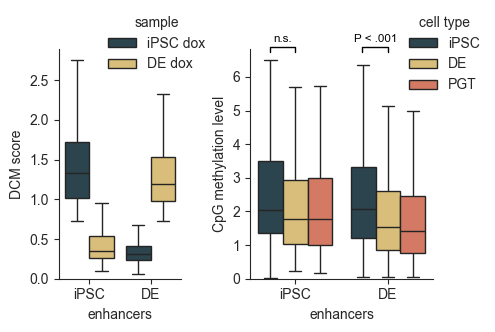

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(5, 3.5), width_ratios=(0.4, 0.6))
sns.boxplot(x="Category", y="DCM", hue="Sample", order=["iPSC", "DE"],
            data=dcm_melt, ax=axs[0], palette={"iPSC dox": palette["iPSC"], "DE dox": palette["DE"]}, showfliers=False)

sns.boxplot(x="Region", y="CpG", hue="Cell type", order=["iPSC", "DE"],
            data=iPSC_DE_melt, ax=axs[1], palette=palette, showfliers=False)

# Adjusted axes
axs[0].set(xlabel="enhancers", ylabel="DCM score", ylim=(0, None))
axs[1].set(xlabel="enhancers", ylabel="CpG methylation level", ylim=(0, None))

# Adjust legends
axs[0].legend(bbox_to_anchor=(0.3, 1.2), loc="upper left", frameon=False, title="sample")
axs[1].legend(bbox_to_anchor=(0.8, 1.2), loc="upper left", frameon=False, title="cell type")

# Add p-values
for axis, y1, y2, x1, x2, label in [[axs[1], 6.75, 6.9, -0.275, 0, p_formatted[0]], 
                                    [axs[1], 6.75, 6.9, 0.725, 1, p_formatted[1]]]:
    axis.plot([x1, x1, x2, x2], [y1, y2, y2, y1], color="black", linewidth=1, clip_on=False)
    axis.text((x1+x2)/2, y2*1.01, label, ha="center", va="bottom", color="black", fontsize="small")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure5j.svg", format="svg")
plt.show()